2025/10/08 11:34:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Gradient Boosting using PSO...


2025/10/08 11:37:37 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7611569590747905, Global best: -0.7611569590747905, Runtime: 104.29845 seconds
2025/10/08 11:40:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7625168668321667, Global best: -0.7625168668321667, Runtime: 152.71444 seconds
2025/10/08 11:42:47 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7625168668321667, Global best: -0.7625168668321667, Runtime: 157.49412 seconds
2025/10/08 11:46:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7693424979561002, Global best: -0.7693424979561002, Runtime: 199.99947 seconds
2025/10/08 11:49:10 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7693424979561002, Global best: -0.7693424979561002, Runtime: 182.64269 seconds
2025/10/08 11:49:10 PM, INFO, mealpy.evolutionary_based.GA.BaseGA

PSO Accuracy: 0.7693
PSO Best Params: {'n_estimators': 189, 'learning_rate': 0.497, 'max_depth': 8}

Optimizing Gradient Boosting using GA...


2025/10/08 11:52:00 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7638829870507459, Global best: -0.7638829870507459, Runtime: 89.20634 seconds
2025/10/08 11:54:19 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7611582015670312, Global best: -0.7638829870507459, Runtime: 139.67777 seconds
2025/10/08 11:56:34 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7611582015670312, Global best: -0.7638829870507459, Runtime: 134.44062 seconds
2025/10/09 12:00:43 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7611582015670312, Global best: -0.7638829870507459, Runtime: 249.29779 seconds
2025/10/09 12:03:45 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7647949763553726, Global best: -0.7647949763553726, Runtime: 182.01051 seconds
2025/10/09 12:03:45 AM, INFO, mealpy.swarm_based.BA.OriginalB

GA Accuracy: 0.7648
GA Best Params: {'n_estimators': 191, 'learning_rate': 0.422, 'max_depth': 7}

Optimizing Gradient Boosting using Bat...


2025/10/09 12:10:13 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.7684373423587969, Global best: -0.7684373423587969, Runtime: 307.03238 seconds
2025/10/09 12:18:12 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.7684373423587969, Global best: -0.7684373423587969, Runtime: 478.58014 seconds
2025/10/09 12:24:46 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.7684373423587969, Global best: -0.7684373423587969, Runtime: 394.64113 seconds
2025/10/09 12:30:09 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.7684373423587969, Global best: -0.7684373423587969, Runtime: 323.08300 seconds
2025/10/09 12:36:15 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.7684373423587969, Global best: -0.7684373423587969, Runtime: 365.71645 seconds


Bat Accuracy: 0.7684
Bat Best Params: {'n_estimators': 139, 'learning_rate': 0.544, 'max_depth': 3}



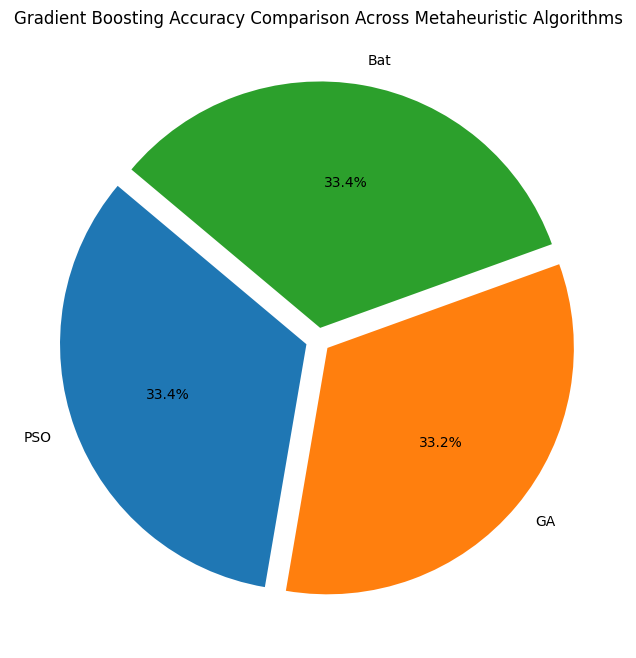

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Gradient Boosting Objective Function
# ----------------------------
def gb_objective_function(solution):
    n_estimators = int(solution[0])
    learning_rate = solution[1]
    max_depth = int(solution[2])
    
    try:
        # Ensure valid hyperparameters
        if n_estimators < 1:
            n_estimators = 50
        if learning_rate <= 0:
            learning_rate = 0.1
        if max_depth < 1:
            max_depth = 3
            
        gb = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42
        )
        scores = cross_val_score(gb, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# Gradient Boosting Problem Definition
# ----------------------------
gb_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),      # Number of trees
        FloatVar(lb=0.01, ub=1.0, name="learning_rate"),  # Learning rate
        FloatVar(lb=1, ub=10, name="max_depth")           # Max depth of each tree
    ],
    "minmax": "min",
    "obj_func": gb_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Gradient Boosting using {name}...")
    best_agent = optimizer.solve(gb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'learning_rate': round(best_solution[1], 3),
        'max_depth': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Gradient Boosting Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()






In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import FA, ABC, CSO
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Gradient Boosting Objective Function
# ----------------------------
def gb_objective_function(solution):
    n_estimators = int(solution[0])
    learning_rate = solution[1]
    max_depth = int(solution[2])
    
    try:
        # Ensure valid hyperparameters
        if n_estimators < 1: n_estimators = 50
        if learning_rate <= 0: learning_rate = 0.1
        if max_depth < 1: max_depth = 3
            
        gb = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42
        )
        scores = cross_val_score(gb, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# Gradient Boosting Problem Definition
# ----------------------------
gb_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),      # Number of trees
        FloatVar(lb=0.01, ub=1.0, name="learning_rate"),  # Learning rate
        FloatVar(lb=1, ub=10, name="max_depth")           # Max depth of each tree
    ],
    "minmax": "min",
    "obj_func": gb_objective_function
}

# ----------------------------
# Only ACO, CSO, FA, ABC Algorithms
# ----------------------------
algorithms = {
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "CSO": CSO.OriginalCSO(epoch=5, pop_size=10),
    "FA": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10),
}

# ----------------------------
# Run Optimization
# ----------------------------
results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Gradient Boosting using {name}...")
    best_agent = optimizer.solve(gb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'learning_rate': round(best_solution[1], 3),
        'max_depth': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Gradient Boosting Accuracy Comparison: ACO vs CSO vs FA vs ABC")
plt.show()


2025/10/09 02:00:59 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: OriginalACOR(epoch=5, pop_size=10, sample_count=25, intent_factor=0.5, zeta=1.0)


Optimizing Gradient Boosting using ACO...
